In [ ]:
# =============================================================================
#  Cell 0 – Imports, paths, configuration, helper functions
# =============================================================================
from pathlib import Path
import fusiproc_utils2 as fu
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn.signal import clean as signal_clean
from typing import Optional, Tuple
import scipy.stats
import json

# -------- dataset paths -------------------------------------------------------
BASE = Path('/Users/clairenastaskin/data/sub-Forest001/2026-01-08/fusi/')
RUNS = sorted([
    'task-audio_run-002/sub-Forest001_ses-20260108_task-audio_run-002_pwd.nii.gz',
    'task-audio_run-005/sub-Forest001_ses-20260108_task-audio_run-005_pwd.nii.gz',
    'task-audio_run-006/sub-Forest001_ses-20260108_task-audio_run-006_pwd.nii.gz',
    'task-audio_run-007/sub-Forest001_ses-20260108_task-audio_run-007_pwd.nii.gz',
    'task-audio_run-009/sub-Forest001_ses-20260108_task-audio_run-009_pwd.nii.gz',
])

SAVE_PATH = Path('/Users/clairenastaskin/data/sub-Forest001/2026-01-08/EV_processing')
SAVE_PATH.mkdir(exist_ok=True)

# -------- analysis switches ---------------------------------------------------
SMOOTH_METHOD  = "none"          # {"none", "boxcar", "savgol"}
SMOOTH_WINDOW  = 3               # if smoothing with boxcar (odd)
FD_THRESH      = 0.5             # mm
RADIUS_MM      = 50.0            # mm for FD sphere
INTENSITY_THRESH = 3.9e4           # <-- adjust per dataset

if SMOOTH_METHOD == "none":
    smooth_tag = "_nosmooth"
elif SMOOTH_METHOD == "boxcar":
    smooth_tag = f"_boxcar{SMOOTH_WINDOW}"


def detect_motion_via_global(
        sig: np.ndarray, t_r: float, k: float = 3.0,
        high_pass: float = 0.01,
        y_lim: Optional[Tuple[float, float]] = None,
        frame_indices: Optional[np.ndarray] = None
) -> tuple[np.ndarray, np.ndarray, plt.Figure]:
    sig_filt = signal_clean(sig.reshape(-1, 1), detrend=True, high_pass=high_pass,
                            standardize=False, t_r=t_r).ravel()
    med = np.median(sig_filt)
    mad = np.median(np.abs(sig_filt - med))
    thr = med + k * mad
    bad = np.where(sig_filt > thr)[0]
    good = np.array([i for i in range(sig.size) if i not in bad], dtype=np.int64)

    x = frame_indices if frame_indices is not None else np.arange(len(sig))

    fig, axes = plt.subplots(1, 1, figsize=(10, 6), sharex=True)
    axes[0].plot(x, sig)
    for f in bad:
        axes[0].axvline(x[f], ls='--', c='r', alpha=.3)
    axes[0].set_title("Global signal with motion outliers")
    axes[0].set_ylabel("Average Intensity")
    if y_lim:
        axes[0].set_ylim(y_lim[0], y_lim[1])
    fig.tight_layout()
    return bad, good, fig


# -------- per-run storage -----------------------------------------------------
R = {}  # dict keyed by run label, stores all per-run results
run_labels = []
for run_path in RUNS:
    label = run_path.split('/')[0]  # e.g. 'task-audio_run-002'
    run_labels.append(label)
    R[label] = {'path': run_path}

print(f"Runs to process ({len(RUNS)}):")
for lbl in run_labels:
    print(f"  {lbl}")

/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Runs to process (5):
  task-audio_run-002
  task-audio_run-005
  task-audio_run-006
  task-audio_run-007
  task-audio_run-009


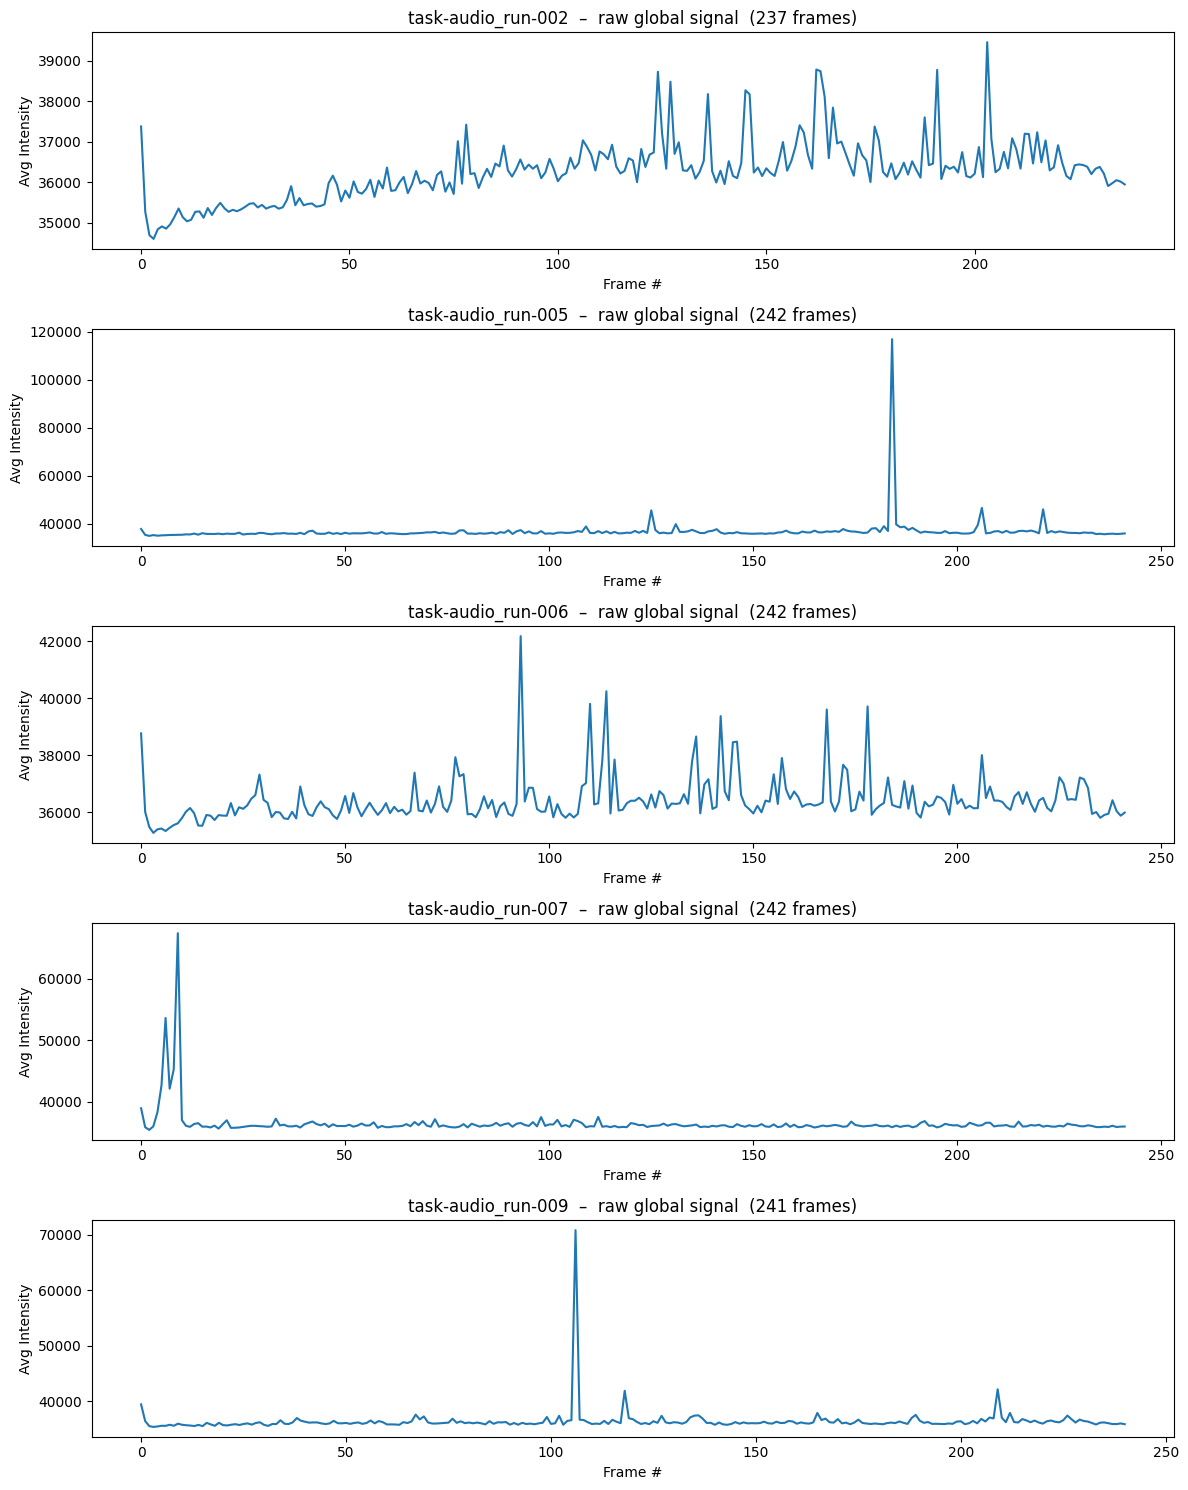


TR = 1.8062 s  (from last run; assumed identical across runs)


In [2]:
# =============================================================================
#  Cell 1 – Load all runs one by one, plot raw global signals
# =============================================================================
fig, axes = plt.subplots(len(run_labels), 1, figsize=(12, 3 * len(run_labels)),
                         sharex=False, squeeze=False)

for i, label in enumerate(run_labels):
    pwd  = BASE / R[label]['path']
    side = BASE / R[label]['path'].replace('_pwd.nii.gz', '_pwd.json')

    data, affine, _ = fu.load_fusi_nifti(pwd)
    mask = fu.nan_mask(data)
    gs   = fu.global_signal(data)
    TR   = fu.repetition_time(side)

    R[label]['data']     = data
    R[label]['affine']   = affine
    R[label]['mask']     = mask
    R[label]['gs']       = gs
    R[label]['TR']       = TR
    R[label]['side']     = side
    R[label]['n_frames'] = data.shape[-1]

    ax = axes[i, 0]
    ax.plot(gs)
    ax.set_title(f"{label}  \u2013  raw global signal  ({data.shape[-1]} frames)")
    ax.set_xlabel("Frame #")
    ax.set_ylabel("Avg Intensity")

fig.tight_layout()
plt.show()
print(f"\nTR = {TR:.4f} s  (from last run; assumed identical across runs)")

task-audio_run-002: 3 frames removed (1 above 3.9e+04 + first 2)
task-audio_run-005: 10 frames removed (8 above 3.9e+04 + first 2)
task-audio_run-006: 8 frames removed (6 above 3.9e+04 + first 2)
task-audio_run-007: 7 frames removed (5 above 3.9e+04 + first 2)
task-audio_run-009: 5 frames removed (4 above 3.9e+04 + first 2)


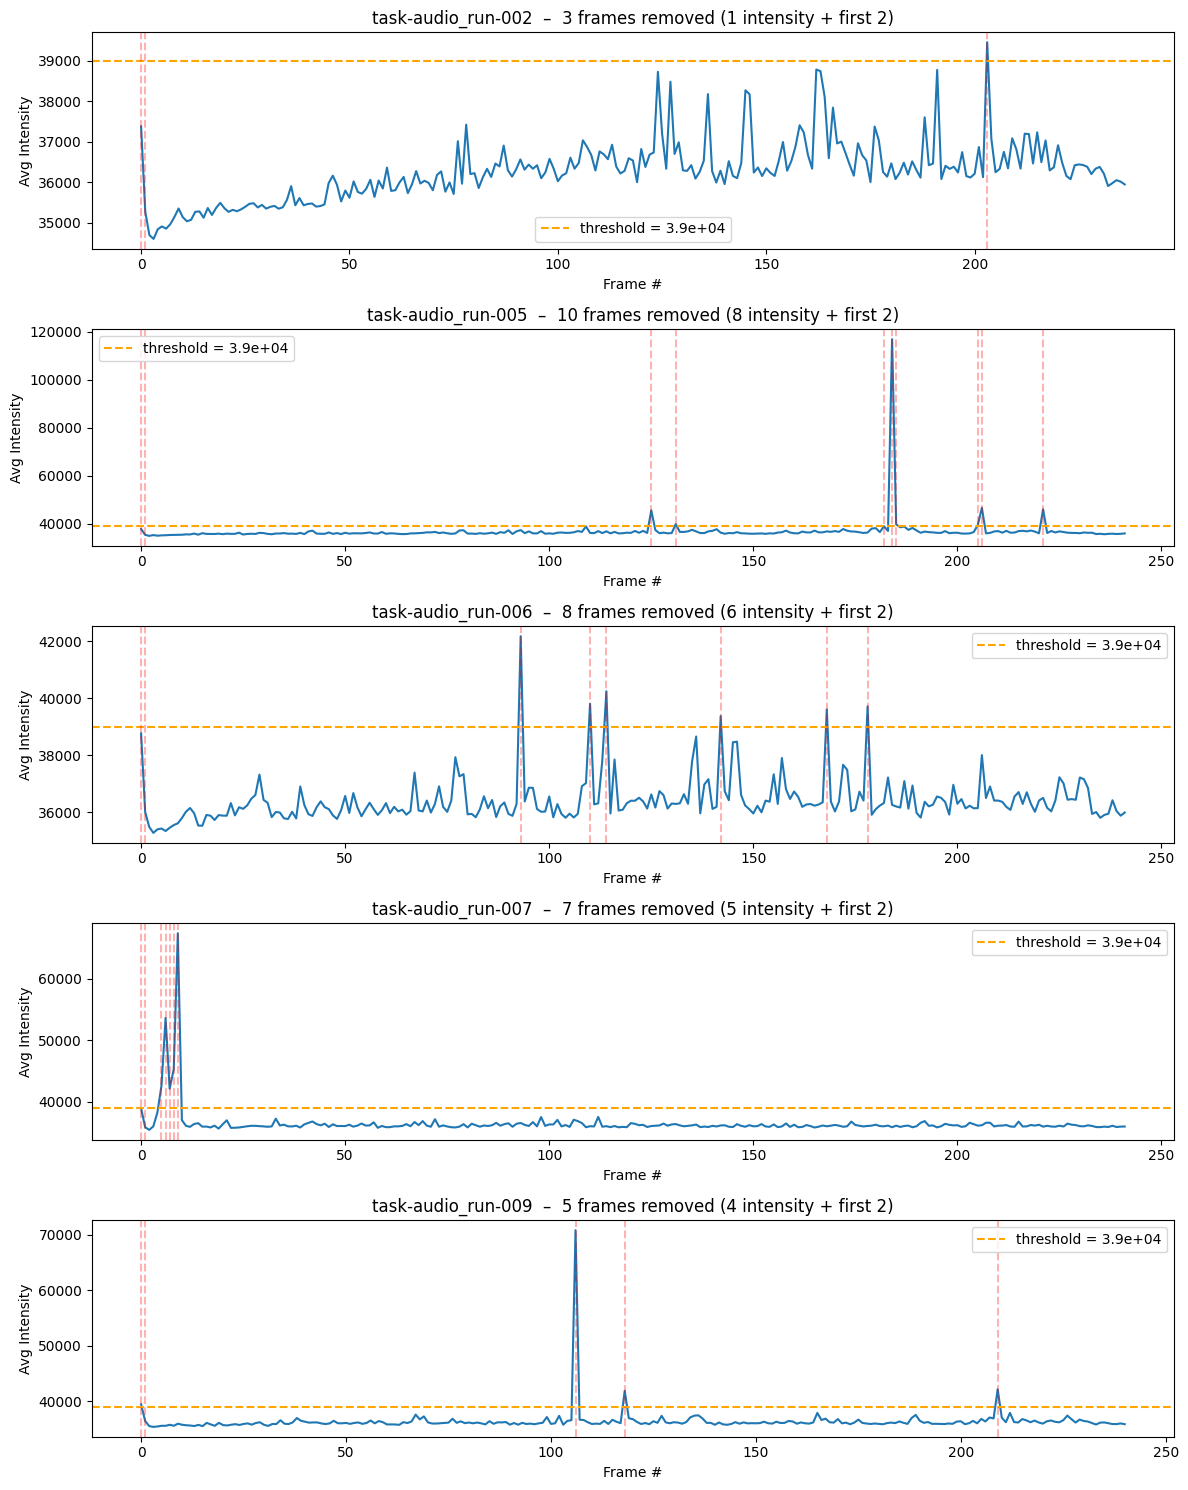

In [3]:
# =============================================================================
#  Cell 2 – Remove frames above an arbitrary intensity threshold (per run)
#           and always remove first two frames (per run)
# =============================================================================
fig, axes = plt.subplots(len(run_labels), 1, figsize=(12, 3 * len(run_labels)),
                         squeeze=False)

for i, label in enumerate(run_labels):
    gs = R[label]['gs']
    bad_intensity = np.where(gs > INTENSITY_THRESH)[0]
    skip = {0, 1}  # always remove first two frames
    skip.update(int(j) for j in bad_intensity)
    R[label]['skip'] = skip

    ax = axes[i, 0]
    ax.plot(gs)
    ax.axhline(INTENSITY_THRESH, ls='--', c='orange',
               label=f'threshold = {INTENSITY_THRESH:.1e}')
    for f in sorted(skip):
        ax.axvline(f, ls='--', c='r', alpha=.3)
    ax.set_title(f"{label}  \u2013  {len(skip)} frames removed "
                 f"({len(bad_intensity)} intensity + first 2)")
    ax.set_xlabel("Frame #")
    ax.set_ylabel("Avg Intensity")
    ax.legend()

    print(f"{label}: {len(skip)} frames removed "
          f"({len(bad_intensity)} above {INTENSITY_THRESH:.1e} + first 2)")

fig.tight_layout()
plt.show()

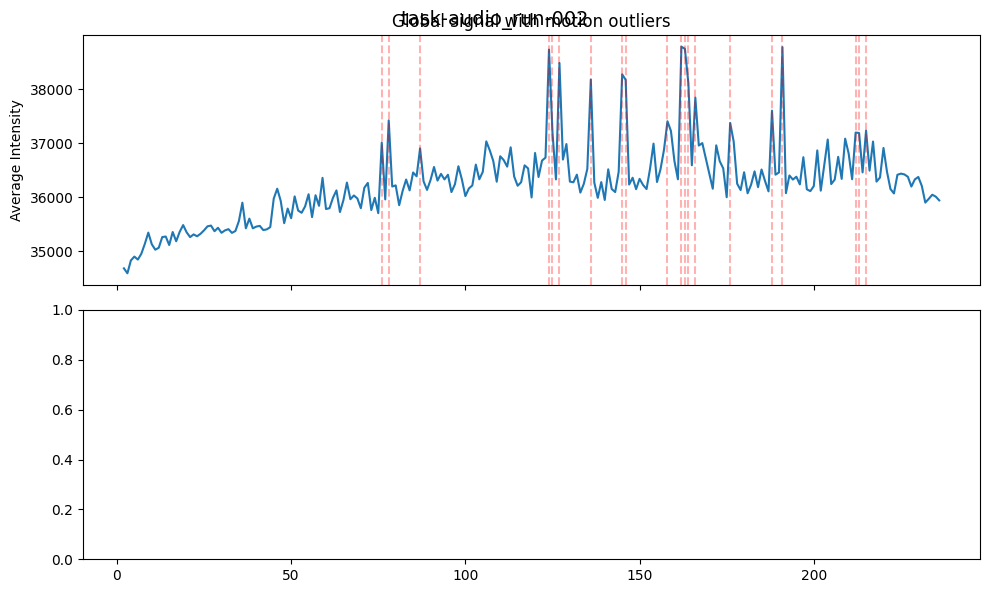

task-audio_run-002: 20 motion outlier frames, 23 total skipped



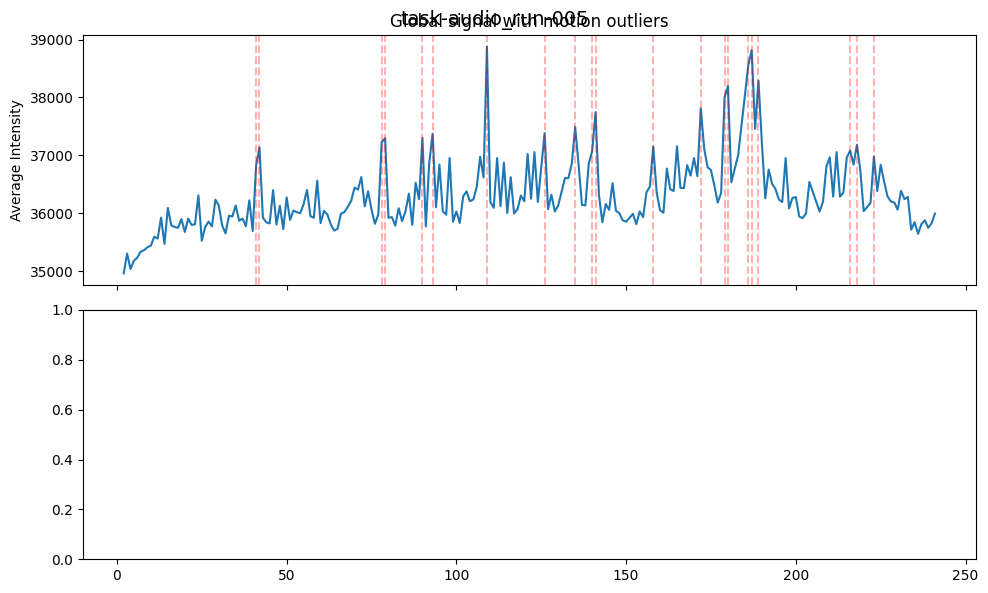

task-audio_run-005: 21 motion outlier frames, 31 total skipped



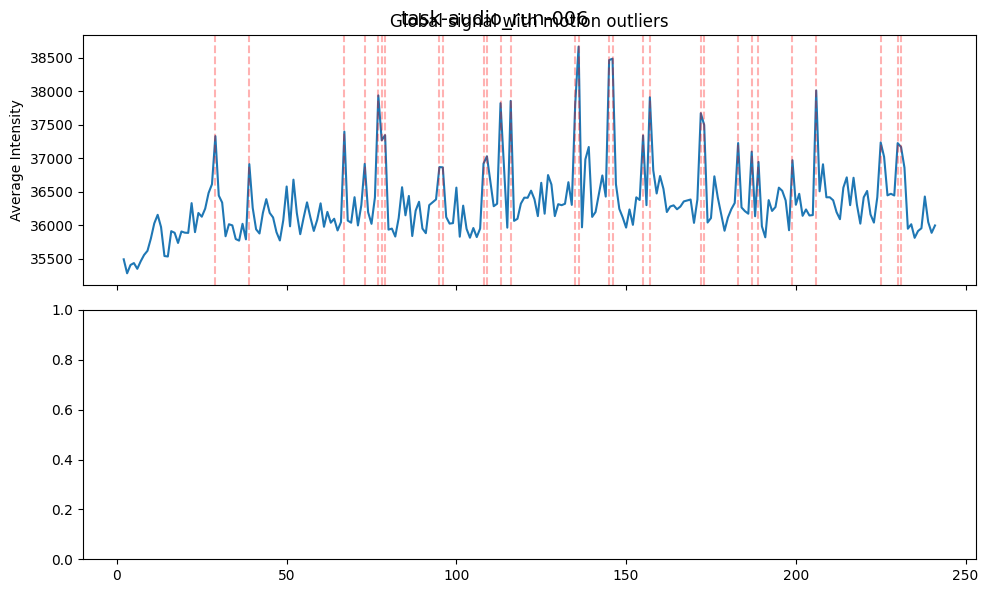

task-audio_run-006: 29 motion outlier frames, 37 total skipped



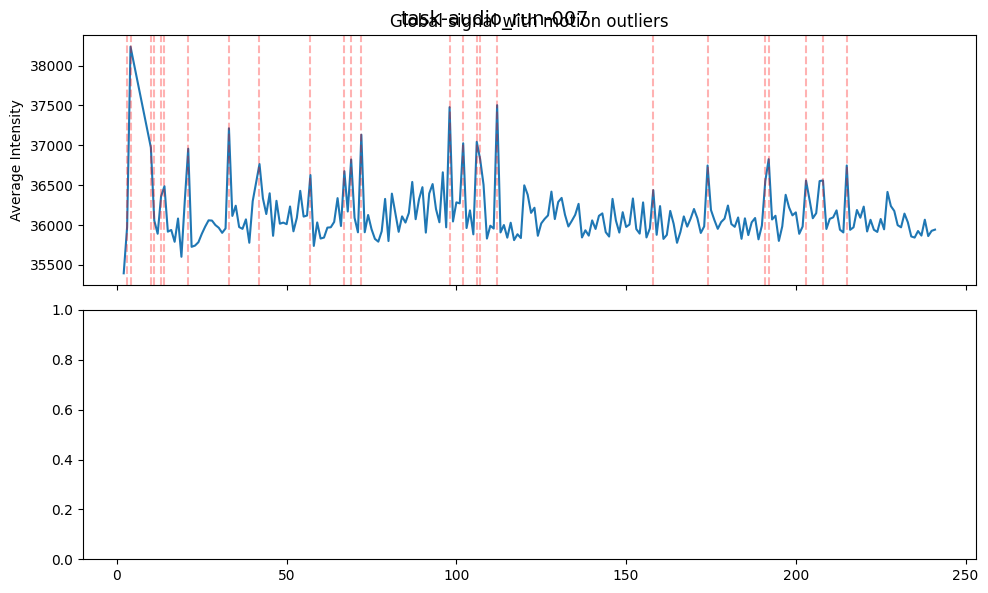

task-audio_run-007: 25 motion outlier frames, 32 total skipped



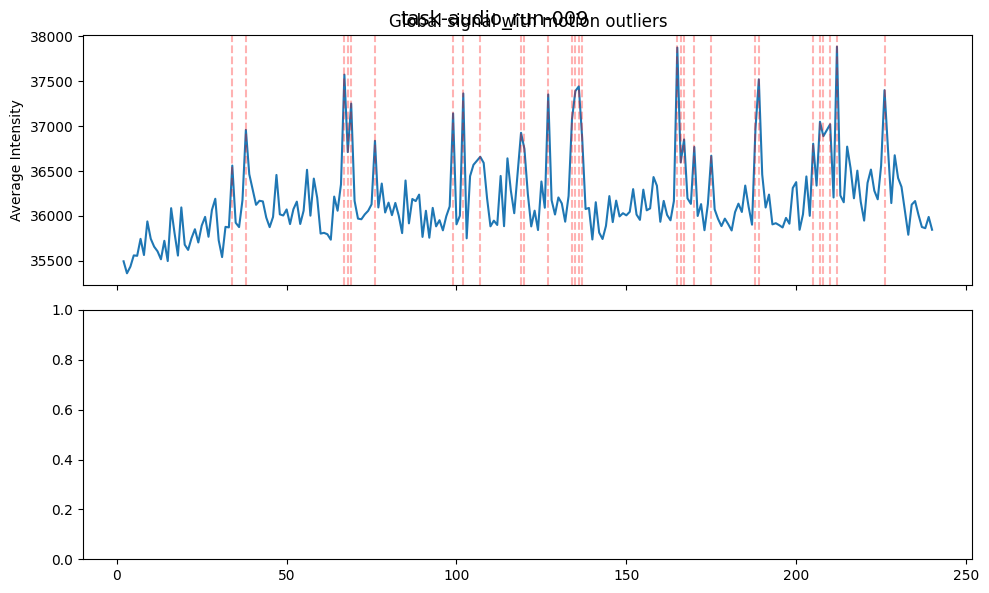

task-audio_run-009: 29 motion outlier frames, 34 total skipped



In [4]:
# =============================================================================
#  Cell 3 – Motion outlier detection via global signal (per run)
# =============================================================================
for label in run_labels:
    gs   = R[label]['gs']
    TR   = R[label]['TR']
    skip = R[label]['skip']

    keep_mask   = np.ones(len(gs), dtype=bool)
    keep_mask[list(skip)] = False
    gs_clean    = gs[keep_mask]
    kept_frames = np.where(keep_mask)[0]

    bad_clean, good_clean, fig = detect_motion_via_global(
        gs_clean, TR, k=3.0, frame_indices=kept_frames)

    bad_gs = kept_frames[bad_clean]
    skip.update(int(j) for j in bad_gs)
    R[label]['skip'] = skip

    run_dir = BASE / label
    fig.savefig(run_dir / "global_signal_with_masked_frame.png")
    fig.suptitle(label, fontsize=14)
    plt.show()

    print(f"{label}: {len(bad_gs)} motion outlier frames, "
          f"{len(skip)} total skipped\n")

In [5]:
# =============================================================================
#  Cell 4 – Rigid registration per run
# =============================================================================
for label in run_labels:
    data   = R[label]['data']
    affine = R[label]['affine']
    mask   = R[label]['mask']
    skip   = R[label]['skip']

    reg_path = BASE / label / "registration"

    if not reg_path.exists():
        reg_path.mkdir(exist_ok=True, parents=True)

        reg, rigid, metric, stop, kept_idx = fu.register_3d_image_stack(
            np.where(np.isfinite(data), data, 0),
            reference='median',
            spacing=np.linalg.norm(affine[:3, :3], axis=0),
            skip_indices=skip,
            mask=mask,
            verbose=True)

        np.save(reg_path / "reg.npy", reg)
        np.save(reg_path / "rigid.npy", rigid)
        np.save(reg_path / "metric.npy", metric)
        np.save(reg_path / "stop.npy", stop)
        np.save(reg_path / "kept_idx.npy", kept_idx)

        html = fu.save_doppler_movie(
            reg, reg_path / "Doppler_movie_after_rigid_registration.mp4")
        display(html)
    else:
        reg      = np.load(reg_path / "reg.npy")
        rigid    = np.load(reg_path / "rigid.npy")
        metric   = np.load(reg_path / "metric.npy")
        stop     = np.load(reg_path / "stop.npy", allow_pickle=True)
        kept_idx = np.load(reg_path / "kept_idx.npy")

    R[label]['reg']      = reg
    R[label]['rigid']    = rigid
    R[label]['metric']   = metric
    R[label]['stop']     = stop
    R[label]['kept_idx'] = kept_idx

    print(f"{label}: registration done \u2013 {len(kept_idx)} frames retained\n")

task-audio_run-002: registration done – 218 frames retained

task-audio_run-005: registration done – 226 frames retained

task-audio_run-006: registration done – 206 frames retained

task-audio_run-007: registration done – 236 frames retained

task-audio_run-009: registration done – 210 frames retained



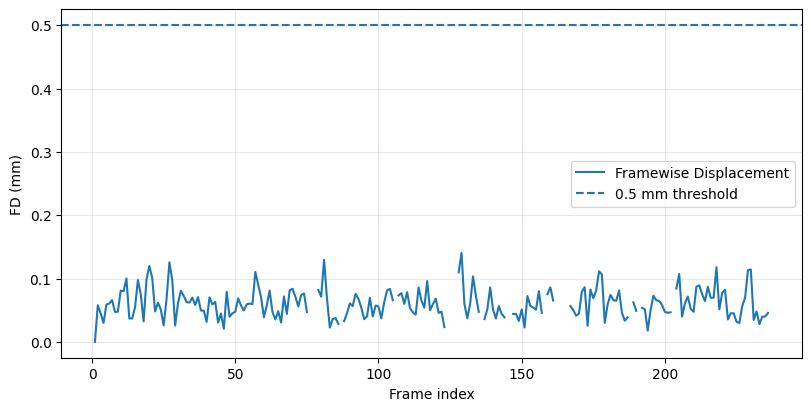

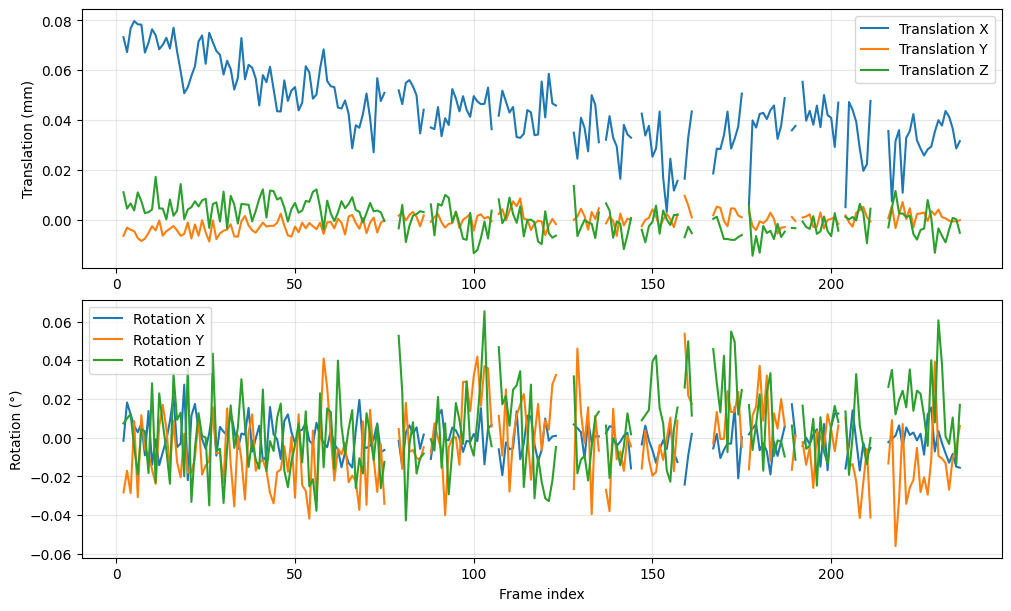

task-audio_run-002: 0 FD outliers, 213/237 frames retained


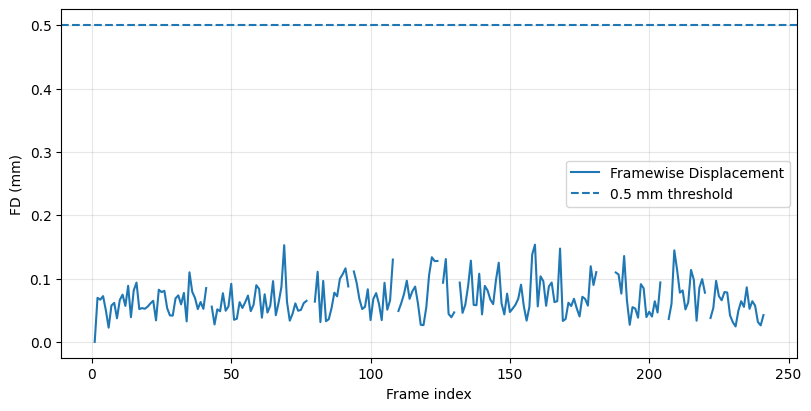

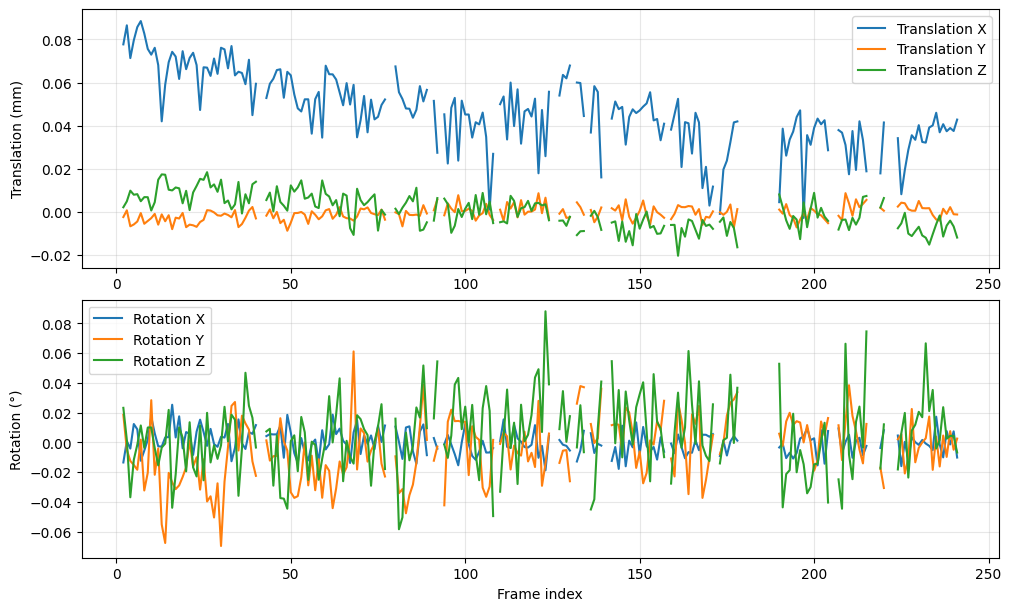

task-audio_run-005: 0 FD outliers, 211/242 frames retained


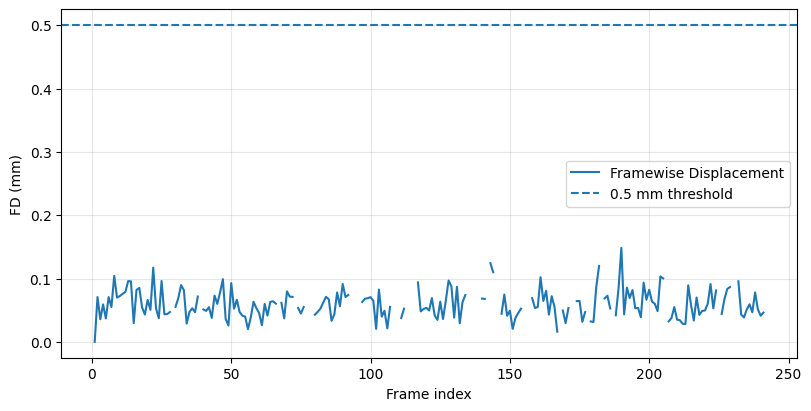

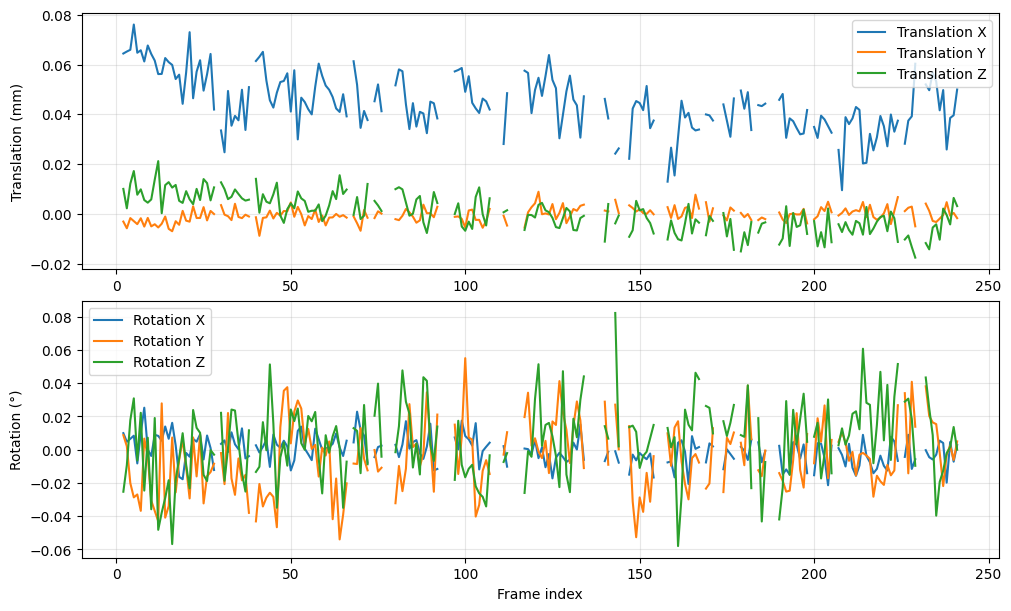

task-audio_run-006: 0 FD outliers, 203/242 frames retained


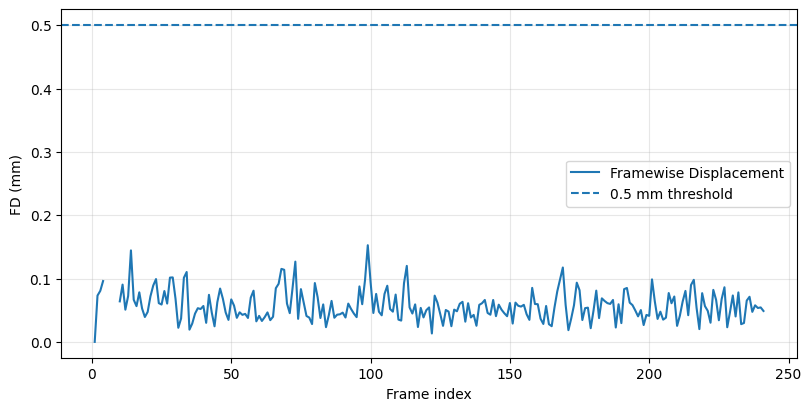

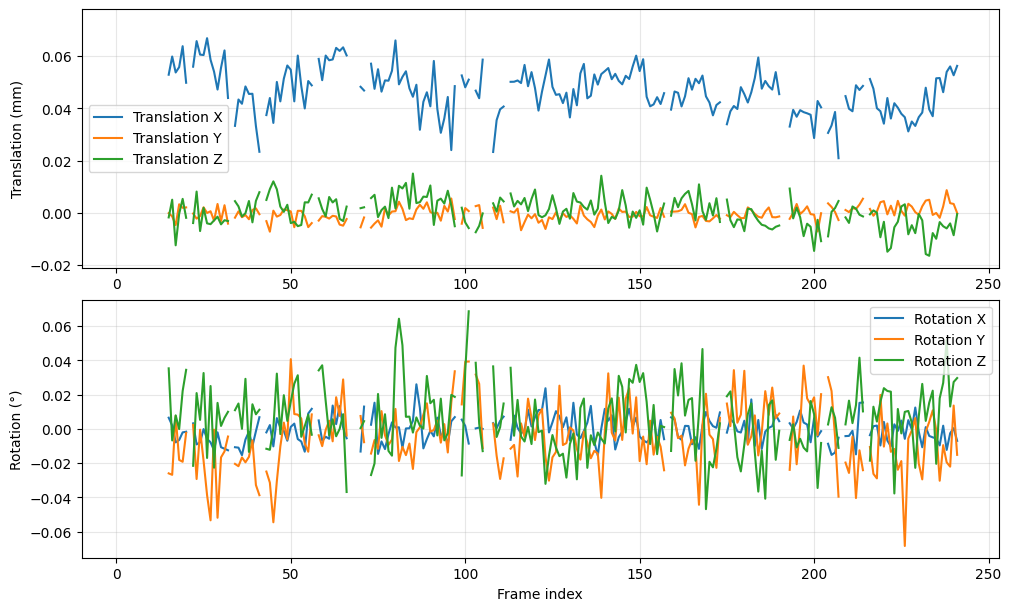

task-audio_run-007: 0 FD outliers, 210/242 frames retained


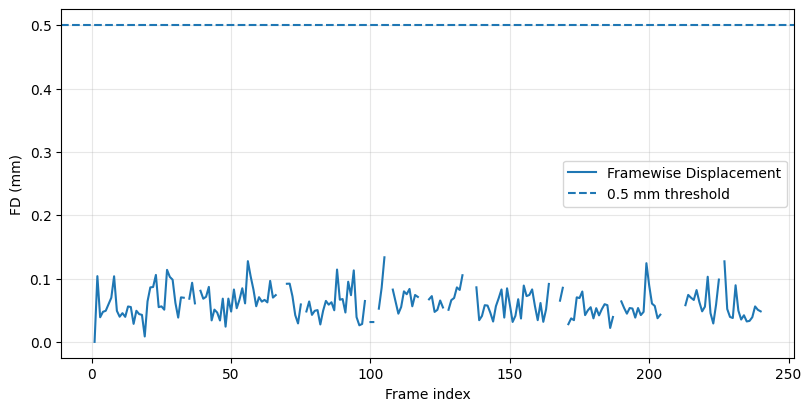

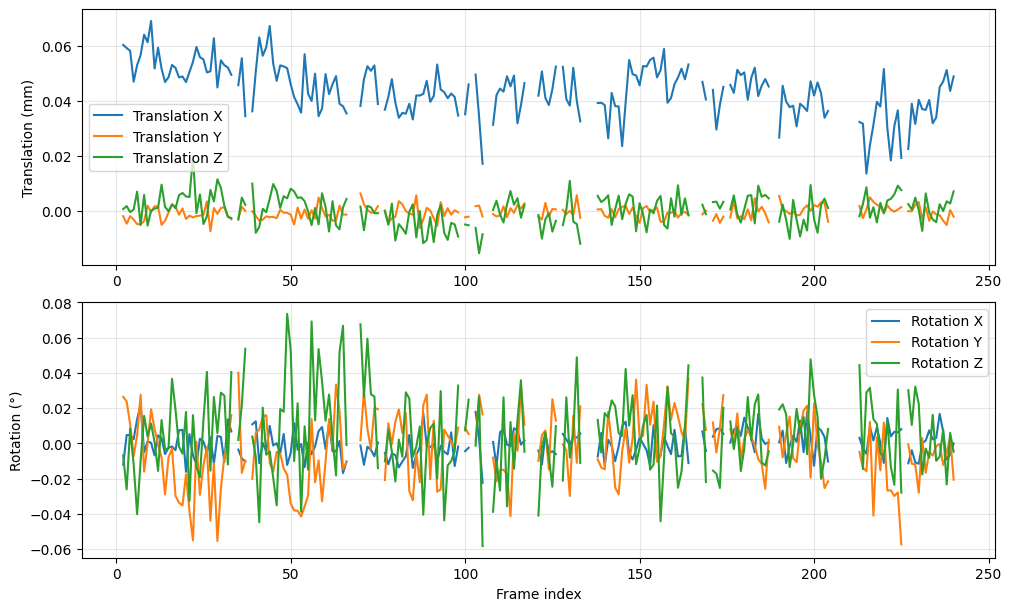

task-audio_run-009: 0 FD outliers, 207/241 frames retained


In [6]:
# =============================================================================
#  Cell 5 – FD outliers, censor list, NaN-padding (per run)
# =============================================================================
for label in run_labels:
    n_frames = R[label]['n_frames']
    rigid    = R[label]['rigid']
    kept_idx = R[label]['kept_idx']
    skip     = R[label]['skip']
    reg      = R[label]['reg']
    metric   = R[label]['metric']
    stop     = R[label]['stop']

    # FD on the gap-free series
    fd      = fu.framewise_displacement(rigid, radius_mm=RADIUS_MM)
    fd_full = np.full(n_frames, np.nan)
    fd_full[kept_idx] = fd

    run_dir = BASE / label
    bad_fd  = fu.plot_fd(fd_full, FD_THRESH, run_dir / "framewise_displacement.png")

    skip.update(int(j) for j in bad_fd)
    R[label]['skip'] = skip

    # Remove newly censored frames
    keep_after_all = [j for j in kept_idx if j not in skip]
    sel = np.isin(kept_idx, keep_after_all)

    reg_use    = reg[..., sel]
    rigid_use  = rigid[:, sel]
    metric_use = metric[sel]
    stop_use   = [s for s, ok in zip(stop, sel) if ok]

    retained = keep_after_all
    reg_full, rigid_full, metric_full, stop_full = fu.reinstate_nans(
        reg_use, rigid_use, metric_use, stop_use, n_frames, retained)

    R[label]['reg_full']    = reg_full
    R[label]['rigid_full']  = rigid_full
    R[label]['retained']    = retained
    R[label]['sample_mask'] = np.array(retained, dtype=int)

    reg_path = BASE / label / "registration"
    fu.plot_registration_parameters(rigid_full, reg_path / "registration.png")

    print(f"{label}: {len(bad_fd)} FD outliers, "
          f"{len(retained)}/{n_frames} frames retained")

In [7]:
# =============================================================================
#  Cell 6 – High-pass filter per run (cutoff = 0.01 Hz)
# =============================================================================
for label in run_labels:
    reg_full    = R[label]['reg_full']
    affine      = R[label]['affine']
    sample_mask = R[label]['sample_mask']
    TR          = R[label]['TR']

    # Optional temporal smoothing before filtering
    if SMOOTH_METHOD == "none":
        smoothed = reg_full.copy()
    elif SMOOTH_METHOD == "boxcar":
        smoothed = fu.boxcar_smooth(reg_full, SMOOTH_WINDOW)

    fusi_data = np.nan_to_num(smoothed)
    nx, ny, nz, nt = fusi_data.shape

    # High-pass filter only retained frames
    good_data  = fusi_data[..., sample_mask]
    voxels_2d  = good_data.reshape(-1, len(sample_mask)).T
    filtered_2d = signal_clean(voxels_2d, high_pass=0.01, t_r=TR,
                               detrend=False, standardize=False)

    # Place filtered frames back into full-length array (NaN for skipped)
    filtered_data = np.full_like(fusi_data, np.nan)
    filtered_data[..., sample_mask] = filtered_2d.T.reshape(
        nx, ny, nz, len(sample_mask))

    R[label]['filtered'] = filtered_data

    # Free memory: we no longer need reg_full for this run
    del R[label]['reg_full']

    print(f"{label}: high-pass filtered \u2013 {len(sample_mask)} retained frames")

task-audio_run-002: high-pass filtered – 213 retained frames
task-audio_run-005: high-pass filtered – 211 retained frames
task-audio_run-006: high-pass filtered – 203 retained frames
task-audio_run-007: high-pass filtered – 210 retained frames
task-audio_run-009: high-pass filtered – 207 retained frames


In [ ]:
# =============================================================================
#  Cell 7 – Concatenate runs temporally + register spatially
#            (on high-pass filtered data so registration has real intensity contrast)
# =============================================================================
import warnings, io, contextlib

# ---- build concatenated array from HIGH-PASS FILTERED data -------------------
all_filtered = []
concat_retained_list = []
run_boundaries = [0]        # frame index where each run starts in concat array
run_offsets = {}             # label -> starting frame in concat

for label in run_labels:
    filtered    = R[label]['filtered']
    sample_mask = R[label]['sample_mask']

    run_offsets[label] = run_boundaries[-1]
    all_filtered.append(filtered)
    concat_retained_list.extend((sample_mask + run_boundaries[-1]).tolist())
    run_boundaries.append(run_boundaries[-1] + filtered.shape[-1])

concat_data     = np.concatenate(all_filtered, axis=-1).astype(np.float32)
concat_retained = np.array(concat_retained_list, dtype=int)
n_total         = concat_data.shape[-1]
concat_skip     = set(range(n_total)) - set(concat_retained.tolist())

# Use affine from first run (all runs share the same geometry)
affine       = R[run_labels[0]]['affine']
mask_concat  = np.all(np.isfinite(concat_data[..., concat_retained]), axis=-1)

print(f"Concatenated shape: {concat_data.shape}")
print(f"Run boundaries:     {run_boundaries}")
print(f"Retained frames:    {len(concat_retained)} / {n_total}")

# Free per-run filtered arrays
for label in run_labels:
    del R[label]['filtered']

# ---- spatial registration of concatenated data --------------------------------
concat_reg_path = SAVE_PATH / "concat_registration"

if not concat_reg_path.exists():
    concat_reg_path.mkdir(exist_ok=True, parents=True)

    with warnings.catch_warnings(), contextlib.redirect_stdout(io.StringIO()):
        warnings.simplefilter("ignore")
        concat_reg, concat_rigid, concat_metric, concat_stop, concat_kept_idx = \
            fu.register_3d_image_stack(
                np.where(np.isfinite(concat_data), concat_data, 0),
                reference='median',
                spacing=np.linalg.norm(affine[:3, :3], axis=0),
                skip_indices=concat_skip,
                mask=mask_concat,
                verbose=False)

    np.save(concat_reg_path / "reg.npy",      concat_reg)
    np.save(concat_reg_path / "rigid.npy",     concat_rigid)
    np.save(concat_reg_path / "metric.npy",    concat_metric)
    np.save(concat_reg_path / "stop.npy",      concat_stop)
    np.save(concat_reg_path / "kept_idx.npy",  concat_kept_idx)
else:
    concat_reg       = np.load(concat_reg_path / "reg.npy")
    concat_rigid     = np.load(concat_reg_path / "rigid.npy")
    concat_metric    = np.load(concat_reg_path / "metric.npy")
    concat_stop      = np.load(concat_reg_path / "stop.npy", allow_pickle=True)
    concat_kept_idx  = np.load(concat_reg_path / "kept_idx.npy")

# ---- NaN-pad the cross-run registration output --------------------------------
keep_after_reg = [i for i in concat_kept_idx if i in set(concat_retained.tolist())]
sel = np.isin(concat_kept_idx, keep_after_reg)

concat_reg_full, concat_rigid_full, _, _ = fu.reinstate_nans(
    concat_reg[..., sel], concat_rigid[:, sel],
    concat_metric[sel],
    [s for s, ok in zip(concat_stop, sel) if ok],
    n_total, keep_after_reg)

concat_sample_mask = np.array(keep_after_reg, dtype=int)

fu.plot_registration_parameters(
    concat_rigid_full, concat_reg_path / "concat_registration.png")

print(f"\nCross-run registration: {len(concat_sample_mask)} frames retained")

In [ ]:
# =============================================================================
#  Cell 8 – Z-score across timepoints within each run (after cross-run registration)
# =============================================================================
nx, ny, nz, nt = concat_reg_full.shape

for i, label in enumerate(run_labels):
    run_start = run_boundaries[i]
    run_end   = run_boundaries[i + 1]

    # Retained frames that fall within this run's range in the concatenated array
    run_mask = concat_sample_mask[(concat_sample_mask >= run_start) &
                                  (concat_sample_mask < run_end)]

    if len(run_mask) < 2:
        print(f"{label}: too few retained frames ({len(run_mask)}), skipping z-score")
        continue

    # Z-score this run's retained frames voxelwise (axis=-1 = time)
    run_data    = concat_reg_full[..., run_mask].copy()   # (x, y, z, n_retained)
    run_zscored = scipy.stats.zscore(run_data, axis=-1, nan_policy='omit')
    concat_reg_full[..., run_mask] = run_zscored

    print(f"{label}: z-scored {len(run_mask)} retained frames "
          f"(concat indices {run_start}..{run_end - 1})")

In [10]:
# =============================================================================
#  Cell 9 – Load events.tsv per run and segment task epochs
# =============================================================================
epochs = []          # (start_idx_in_concat, end_idx_in_concat)
epoch_labels = []    # which run each epoch came from

for label in run_labels:
    side_path = BASE / R[label]['path'].replace('_pwd.nii.gz', '_pwd.json')
    with open(side_path, 'r') as f:
        sidecar = json.load(f)
    vol_times = np.array(sidecar["VolumeTiming"])

    # Find the events.tsv in SAVE_PATH
    ev_paths = list(SAVE_PATH.glob('*events.tsv'))
    assert ev_paths, f"No events.tsv found in {SAVE_PATH}"
    events = pd.read_csv(ev_paths[0], sep='\t')

    offset = run_offsets[label]
    print(f"\n{label}  (offset={offset} frames):")
    print(events[['onset', 'duration', 'trial_type']].to_string())

    for _, row in events.iterrows():
        onset      = row['onset']
        offset_sec = onset + row['duration']
        start_idx  = np.argmin(np.abs(vol_times - onset))
        end_idx    = np.argmin(np.abs(vol_times - offset_sec))

        # Shift to concatenated indices
        epochs.append((start_idx + offset, end_idx + offset))
        epoch_labels.append(label)
        print(f"  Onset {onset:8.1f}s \u2192 vol {start_idx + offset:5d}  |  "
              f"Offset {offset_sec:8.1f}s \u2192 vol {end_idx + offset:5d}  |  "
              f"n_vols = {end_idx - start_idx}")

n_vols_per_epoch = min(end - start for start, end in epochs)
N_rep = len(epochs)
print(f"\n{N_rep} epochs total, using {n_vols_per_epoch} volumes per epoch "
      f"(trimmed to shortest)")


task-audio_run-002  (offset=0 frames):
       onset  duration       trial_type
0  13.771989   407.162  BBC_earth_3.mp4
  Onset     13.8s → vol     7  |  Offset    420.9s → vol   232  |  n_vols = 225

task-audio_run-005  (offset=237 frames):
       onset  duration       trial_type
0  13.771989   407.162  BBC_earth_3.mp4
  Onset     13.8s → vol   244  |  Offset    420.9s → vol   469  |  n_vols = 225

task-audio_run-006  (offset=479 frames):
       onset  duration       trial_type
0  13.771989   407.162  BBC_earth_3.mp4
  Onset     13.8s → vol   486  |  Offset    420.9s → vol   710  |  n_vols = 224

task-audio_run-007  (offset=721 frames):
       onset  duration       trial_type
0  13.771989   407.162  BBC_earth_3.mp4
  Onset     13.8s → vol   728  |  Offset    420.9s → vol   952  |  n_vols = 224

task-audio_run-009  (offset=963 frames):
       onset  duration       trial_type
0  13.771989   407.162  BBC_earth_3.mp4
  Onset     13.8s → vol   970  |  Offset    420.9s → vol  1195  |  n_vol

In [11]:
# =============================================================================
#  Cell 10 – Explainable Variance
# =============================================================================
nx, ny, nz, nt = concat_reg_full.shape

# 1. Voxel mask: voxels always inside the FOV across all retained frames
retained_data = concat_reg_full[..., concat_sample_mask]
voxel_mask    = np.all(np.isfinite(retained_data), axis=-1)
valid_idx     = np.where(voxel_mask.ravel())[0]
n_valid       = len(valid_idx)
print(f"Valid voxels (always inside FOV): {n_valid} / {nx*ny*nz}")

# 2. Extract epochs (only valid voxels)
Y = np.empty((N_rep, n_vols_per_epoch, n_valid))
for i, (start, _) in enumerate(epochs):
    epoch_data = concat_reg_full[..., start:start + n_vols_per_epoch]
    Y[i] = epoch_data.reshape(-1, n_vols_per_epoch)[valid_idx].T

# 3. Valid timepoints: not a skipped frame in ANY epoch
time_valid = np.all(np.isfinite(Y), axis=(0, 2))
Y_ev = Y[:, time_valid, :]
Y_ev = scipy.stats.zscore(Y_ev, axis=1)   # z-score within each epoch
print(f"Valid timepoints per epoch: {time_valid.sum()} / {n_vols_per_epoch}")
print(f"Y_ev shape: {Y_ev.shape}  (repeats x timepoints x voxels)")

# 4. Explainable variance  (Sahani & Linden, 2003)
mean_response      = Y_ev.mean(axis=0)                    # (T, V)
var_mean_response  = np.var(mean_response, axis=0)        # (V,)
var_responses      = np.var(Y_ev, axis=1)                 # (N, V)
mean_var_responses = np.mean(var_responses, axis=0)       # (V,)

ev_sahani = (1 / (N_rep - 1)
             * (N_rep * var_mean_response - mean_var_responses))

# Normalised fraction (divide by total variance)
ev_sahani = ev_sahani / mean_var_responses

# Map back to full volume
ev_vol = np.full(nx * ny * nz, np.nan)
ev_vol[valid_idx] = ev_sahani
ev_vol = ev_vol.reshape(nx, ny, nz)
ev = ev_sahani

print(f"\nEV  min: {np.nanmin(ev_vol):.4f}   "
      f"median: {np.nanmedian(ev_vol):.4f}   "
      f"max: {np.nanmax(ev_vol):.4f}")

Valid voxels (always inside FOV): 294840 / 294840
Valid timepoints per epoch: 116 / 224
Y_ev shape: (5, 116, 294840)  (repeats x timepoints x voxels)

EV  min: -0.1233   median: -0.0004   max: 0.1977


Saved: /Users/clairenastaskin/data/sub-Forest001/2026-01-08/EV_processing/explainable_variance_map.nii.gz
Saved: /Users/clairenastaskin/data/sub-Forest001/2026-01-08/EV_processing/explainable_variance_map.npy


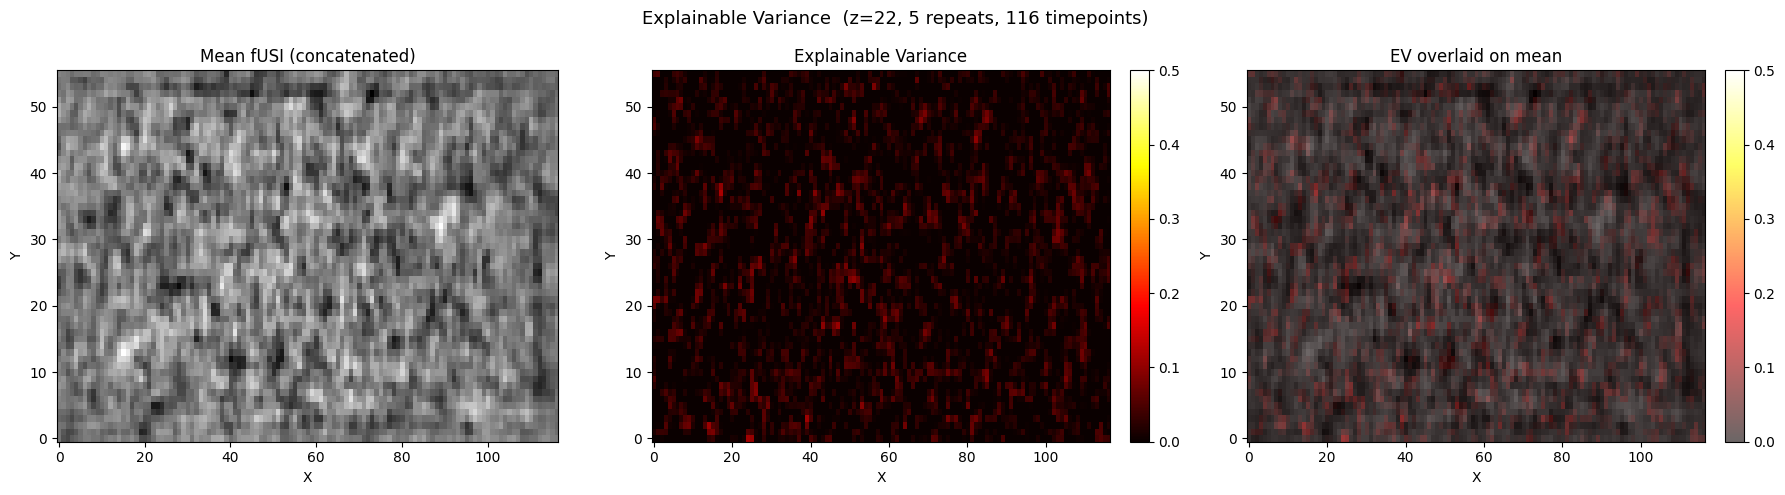

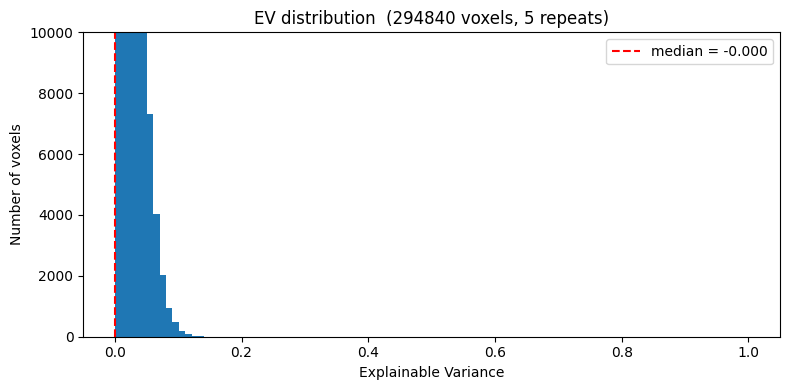

In [12]:
# =============================================================================
#  Cell 11 – Save and plot explainable variance
# =============================================================================

# ---- save --------------------------------------------------------------------
ev_img = nib.Nifti1Image(ev_vol, affine)
ev_img.to_filename(SAVE_PATH / "explainable_variance_map.nii.gz")
np.save(SAVE_PATH / "explainable_variance_map.npy", ev_vol)
print(f"Saved: {SAVE_PATH / 'explainable_variance_map.nii.gz'}")
print(f"Saved: {SAVE_PATH / 'explainable_variance_map.npy'}")

# ---- save clean mean for overlay ---------------------------------------------
mean_concat = np.nanmean(concat_reg_full, axis=-1)
fu.save_nifti(mean_concat, affine, SAVE_PATH / "concat_mean.nii.gz")

# ---- slice views -------------------------------------------------------------
mid_z = nz // 2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(mean_concat[:, :, mid_z].T, origin='lower', cmap='gray',
               aspect='auto')
axes[0].set_title("Mean fUSI (concatenated)")

im1 = axes[1].imshow(ev_vol[:, :, mid_z].T, origin='lower', cmap='hot',
                      vmin=0, vmax=0.5, aspect='auto')
axes[1].set_title("Explainable Variance")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(mean_concat[:, :, mid_z].T, origin='lower', cmap='gray',
               aspect='auto')
im2 = axes[2].imshow(ev_vol[:, :, mid_z].T, origin='lower', cmap='hot',
                      alpha=0.6, vmin=0, vmax=0.5, aspect='auto')
axes[2].set_title("EV overlaid on mean")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xlabel("X"); ax.set_ylabel("Y")
fig.suptitle(f"Explainable Variance  (z={mid_z}, {N_rep} repeats, "
             f"{time_valid.sum()} timepoints)", fontsize=13)
fig.tight_layout()
fig.savefig(SAVE_PATH / "explainable_variance_map.png", dpi=300)
plt.show()

# ---- histogram ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ev[np.isfinite(ev)], bins=np.linspace(0, 1, 100), edgecolor='none')
ax.set_xlabel("Explainable Variance")
ax.set_ylabel("Number of voxels")
ax.set_ylim(0, 10000)
ax.set_title(f"EV distribution  ({n_valid} voxels, {N_rep} repeats)")
ax.axvline(np.nanmedian(ev), ls='--', c='r',
           label=f'median = {np.nanmedian(ev):.3f}')
ax.legend()
fig.tight_layout()
fig.savefig(SAVE_PATH / "explainable_variance_histogram.png", dpi=150)
plt.show()

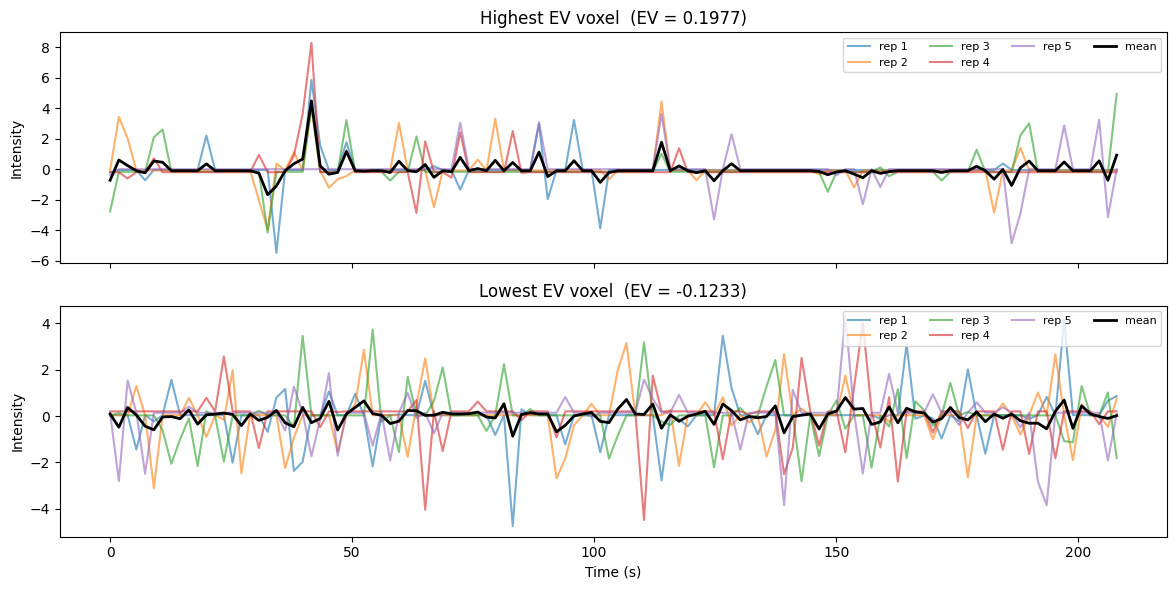

In [13]:
# =============================================================================
#  Cell 12 – Overlaid timecourses: highest vs lowest EV voxels
# =============================================================================
TR_use = R[run_labels[0]]['TR']
t_sec  = np.arange(time_valid.sum()) * TR_use

best_vox  = np.nanargmax(ev)
worst_vox = np.nanargmin(ev)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for rep in range(N_rep):
    axes[0].plot(t_sec, Y_ev[rep, :, best_vox], alpha=0.6, label=f'rep {rep+1}')
axes[0].plot(t_sec, mean_response[:, best_vox], 'k-', lw=2, label='mean')
axes[0].set_ylabel("Intensity")
axes[0].set_title(f"Highest EV voxel  (EV = {ev[best_vox]:.4f})")
axes[0].legend(loc='upper right', ncol=4, fontsize=8)

for rep in range(N_rep):
    axes[1].plot(t_sec, Y_ev[rep, :, worst_vox], alpha=0.6, label=f'rep {rep+1}')
axes[1].plot(t_sec, mean_response[:, worst_vox], 'k-', lw=2, label='mean')
axes[1].set_ylabel("Intensity")
axes[1].set_xlabel("Time (s)")
axes[1].set_title(f"Lowest EV voxel  (EV = {ev[worst_vox]:.4f})")
axes[1].legend(loc='upper right', ncol=4, fontsize=8)

fig.tight_layout()
fig.savefig(SAVE_PATH / "ev_timecourses_best_worst.png", dpi=150)
plt.show()